<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/VAE_Aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importando bibliotecas necessárias
!pip install -q torch_snippets #biblioteca Pytorch Snippets
from torch_snippets import *
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid
#inicializa o dispositivo para 'cuda' ou 'cpu'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# conjuntos de dados de teino e teste para o MNIST
train_dataset = datasets.MNIST(root='MNIST/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='MNIST/', train=False, transform=transforms.ToTensor(), download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.2/226.2 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.6/157.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.2/398.2 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.6/470.6 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 79.9 MB/s eta 0:00:00


100%|██████████| 9.91M/9.91M [00:00<00:00, 66.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]


In [2]:
train_dataset[0][0]

tensor[1, 28, 28] n=784 (3.06 KiB) x∈[0. |█▁▁▁▁▁▁▁▁▁| 1.000] μ=0.138 σ=0.313

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder network
        #redes de codificação
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1) # duas camadas convoluicionais
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 256) # duas camadas totalmente conectadas
        self.fc21 = nn.Linear(256, 20) # mu
        self.fc22 = nn.Linear(256, 20) # logvar

        #Decoder network
        # redes de decodificação
        self.fc3 = nn.Linear(20, 256)
        self.fc4 = nn.Linear(256, 64 * 7 * 7)
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.deconv2 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1)

    def encode(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        mu = self.fc21(x)
        logvar = self.fc22(x)
        return mu, logvar
    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = Variable(torch.randn(std.size()).to(device))
            return eps.mul(std).add_(mu)
        else:
            return mu
    def decode(self, z):
        z = F.relu(self.fc3(z))
        z = F.relu(self.fc4(z))
        z = z.view(z.size(0), 64, 7, 7)
        z = F.relu(self.deconv1(z))
        z = torch.sigmoid(self.deconv2(z))
        return z
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        z = self.decode(z)
        return z, mu, logvar

In [4]:
# função de treinar e validar o VAE
def train_batch(data,model,optimizer,loss_function):
    model.train()
    data = data.to(device)
    optimizer.zero_grad()
    recon_batch, mean, log_var = model(data)
    # calculando a perda em um lote de imagens
    loss,mse,kld = loss_function(recon_batch, data, mean, log_var)
    loss.backward()
    optimizer.step()
    return loss, mse, kld, log_var.mean(), mean.mean()


@torch.no_grad()
def validate_batch(data,model,loss_function):
    model.eval()
    data = data.to(device)
    recon,mean,log_var = model(data)
    loss, mse, kld = loss_function(recon,data,mean,log_var)
    return loss, mse, kld, log_var.mean(), mean.mean()

In [5]:
def loss_function(recon_x, x, mean, log_var):
    RECON = F.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1+log_var-mean.pow(2) - log_var.exp())
    return RECON + KLD, RECON, KLD

EPOCH: 1.000  train_loss: 2631.327  train_log_var: -0.643  train_mean: -0.003  val_kld: 627.439  val_recon: 1197.447  train_kld: 436.413  val_loss: 1824.886  val_log_var: -0.970  val_mean: 0.032  train_recon: 2194.914  (78.70s - 708.28s remaining)


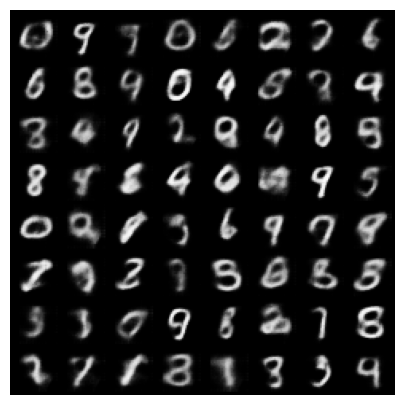

EPOCH: 2.000  train_loss: 2010.673  train_log_var: -1.014  train_mean: 0.000  val_kld: 665.502  val_recon: 960.913  train_kld: 654.478  val_loss: 1626.415  val_log_var: -1.053  val_mean: 0.011  train_recon: 1356.195  (166.21s - 664.83s remaining)


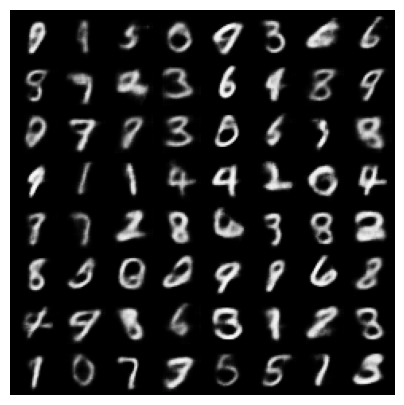

EPOCH: 3.000  train_loss: 1918.070  train_log_var: -1.080  train_mean: 0.000  val_kld: 716.399  val_recon: 882.233  train_kld: 694.173  val_loss: 1598.632  val_log_var: -1.122  val_mean: 0.005  train_recon: 1223.897  (254.74s - 594.39s remaining)


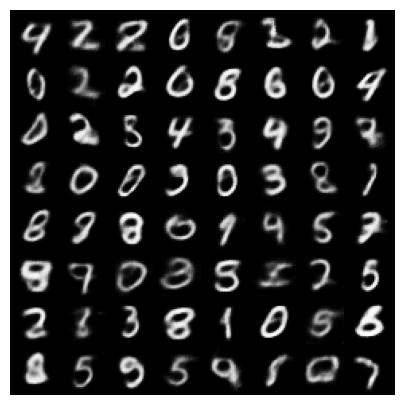

EPOCH: 4.000  train_loss: 1874.647  train_log_var: -1.112  train_mean: 0.001  val_kld: 737.619  val_recon: 834.522  train_kld: 713.145  val_loss: 1572.141  val_log_var: -1.143  val_mean: 0.016  train_recon: 1161.502  (347.87s - 521.80s remaining)


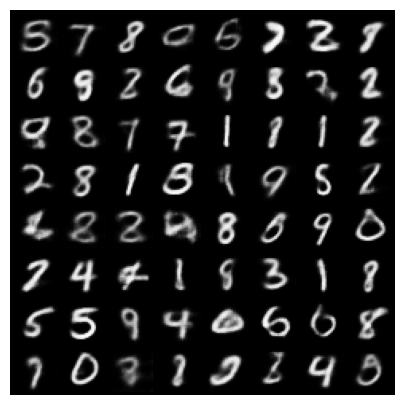

EPOCH: 5.000  train_loss: 1845.886  train_log_var: -1.130  train_mean: 0.002  val_kld: 720.332  val_recon: 820.847  train_kld: 724.360  val_loss: 1541.179  val_log_var: -1.137  val_mean: -0.008  train_recon: 1121.525  (436.93s - 436.93s remaining)


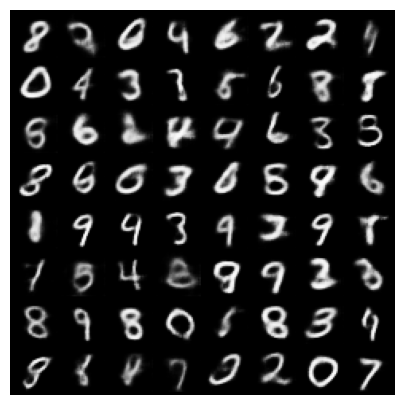

EPOCH: 6.000  train_loss: 1827.437  train_log_var: -1.145  train_mean: 0.001  val_kld: 778.914  val_recon: 785.506  train_kld: 733.438  val_loss: 1564.420  val_log_var: -1.195  val_mean: 0.002  train_recon: 1093.998  (528.63s - 352.42s remaining)


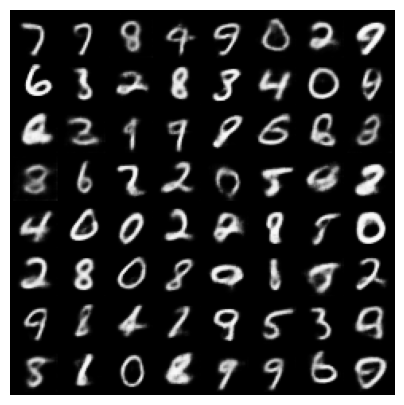

EPOCH: 7.000  train_loss: 1812.725  train_log_var: -1.155  train_mean: 0.001  val_kld: 716.103  val_recon: 766.171  train_kld: 739.419  val_loss: 1482.274  val_log_var: -1.136  val_mean: 0.013  train_recon: 1073.307  (618.75s - 265.18s remaining)


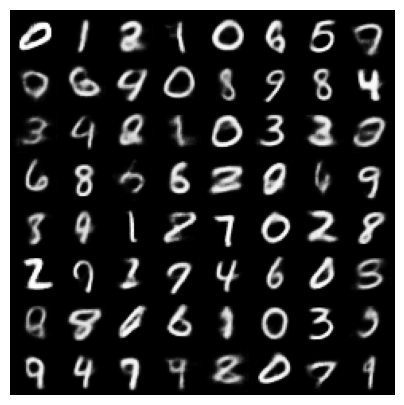

EPOCH: 8.000  train_loss: 1797.401  train_log_var: -1.160  train_mean: 0.000  val_kld: 725.119  val_recon: 773.633  train_kld: 742.730  val_loss: 1498.752  val_log_var: -1.147  val_mean: 0.017  train_recon: 1054.672  (709.68s - 177.42s remaining)


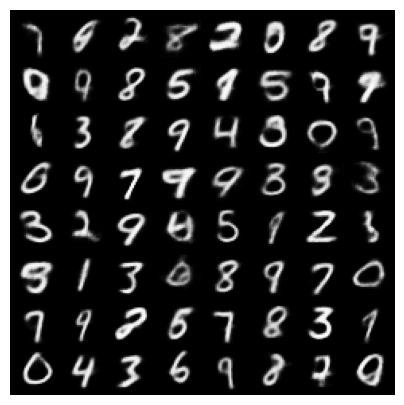

EPOCH: 9.000  train_loss: 1786.677  train_log_var: -1.166  train_mean: 0.001  val_kld: 756.102  val_recon: 737.962  train_kld: 746.268  val_loss: 1494.064  val_log_var: -1.182  val_mean: 0.004  train_recon: 1040.408  (799.51s - 88.83s remaining)


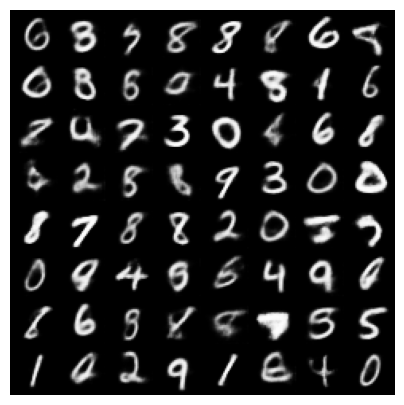

EPOCH: 10.000  train_loss: 1778.707  train_log_var: -1.170  train_mean: 0.000  val_kld: 747.745  val_recon: 738.145  train_kld: 748.994  val_loss: 1485.890  val_log_var: -1.178  val_mean: 0.012  train_recon: 1029.714  (891.51s - 0.00s remaining)


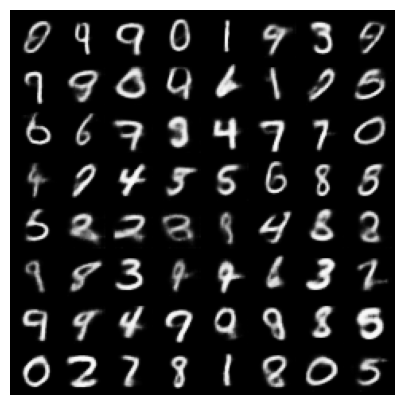

In [6]:
# conjunto de dados MNIST para 10 épocas
n_epochs = 10
log = Report(n_epochs)
vae = VAE().to(device)
optimizer = optim.AdamW(vae.parameters(), lr=1e-3)

# para cada época, calcula a perda em um lote de imagem
for epoch in range(n_epochs):
    N = len(train_loader)
    for batch_idx, (data, _) in enumerate(train_loader):
        loss, recon, kld, log_var, mean = train_batch(data, vae, optimizer, loss_function)
        pos = epoch + (1+batch_idx)/N
        log.record(pos, train_loss=loss, train_kld=kld, train_recon=recon, train_log_var=log_var, train_mean=mean, end='\r')

    N = len(test_loader)
    for batch_idx, (data, _) in enumerate(test_loader):
        loss, recon, kld, log_var, mean = validate_batch(data, vae, loss_function)
        pos = epoch + (1+batch_idx)/N
        log.record(pos, val_loss=loss, val_kld=kld, val_recon=recon, val_log_var=log_var, val_mean=mean, end='\r')

    log.report_avgs(epoch+1)
    with torch.no_grad():
        z = torch.randn(64, 20).to(device)
        sample = vae.decode(z).to(device)
        images = make_grid(sample.view(64, 1, 28, 28)).permute(1,2,0)
        show(images)